# Pertemuan 5: Visualisasi Data
### Dashboard Visualisasi Statis

| | |
|---|---|
| **Nama Lengkap** | Nisa Agustina Maesaroh |
| **NIM** | 240401070509 |
| **Kelas** | IF403 |


In [19]:
#import library & load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set tema global Seaborn
sns.set_theme(style='whitegrid', palette='Set2')

# LOAD & INSPECT DATASET
df = sns.load_dataset('tips')
print('Shape dataset:', df.shape)
print('\nInfo kolom:')
print(df.dtypes)
print('\nStatistik deskriptif:')
df.describe().round(2)

Shape dataset: (244, 7)

Info kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik deskriptif:


,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


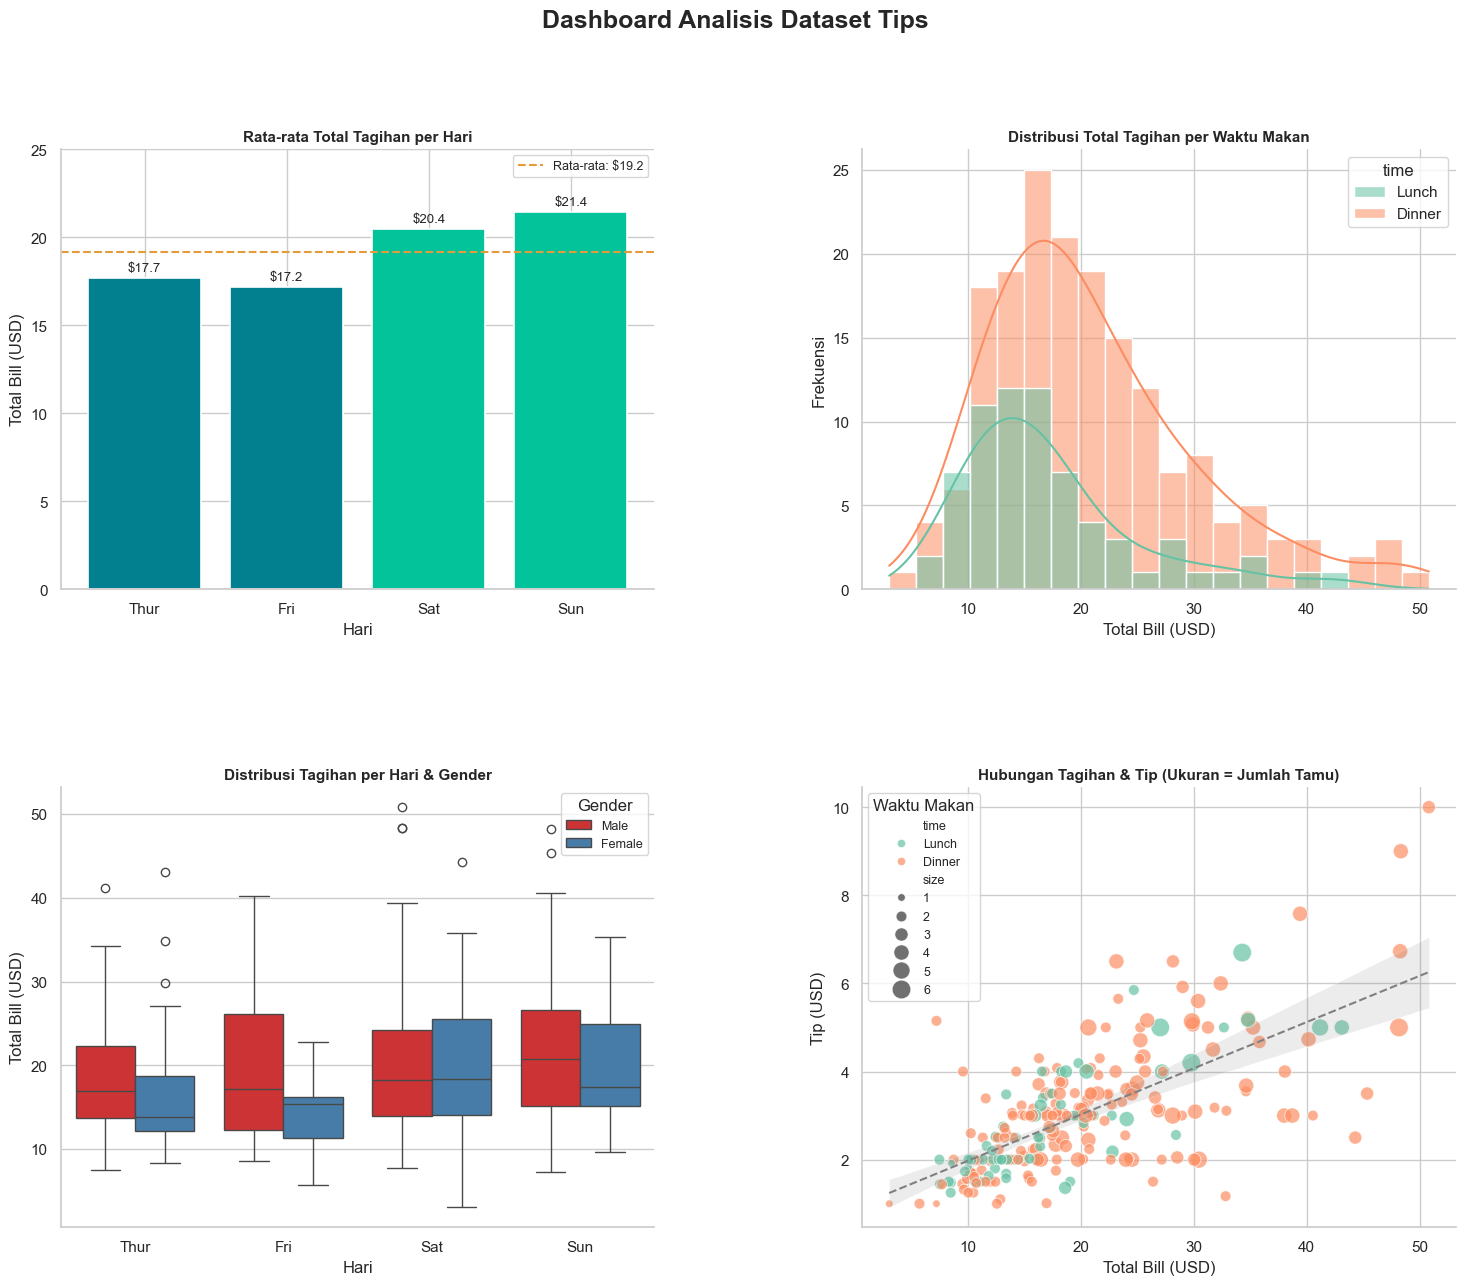

Dashboard tersimpan sebagai dashboard_tips.png


In [20]:
#DASHBOARD

# ── SETUP FIGURE LAYOUT ──
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Dashboard Analisis Dataset Tips',
    fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])   # kiri atas
ax2 = fig.add_subplot(gs[0, 1])   # kanan atas
ax3 = fig.add_subplot(gs[1, 0])   # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])   # kanan bawah

# ── GRAFIK 1: Bar Chart ──
avg_by_day = df.groupby('day')['total_bill'].mean().reindex(['Thur', 'Fri', 'Sat', 'Sun'])
colors_bar = ['#028090' if v < avg_by_day.mean() else '#02C39A' for v in avg_by_day]
bars = ax1.bar(avg_by_day.index, avg_by_day.values, color=colors_bar, edgecolor='white', linewidth=1.2)
ax1.axhline(avg_by_day.mean(), color='#E69B3A', linestyle='--', linewidth=1.5,
            label=f'Rata-rata: ${avg_by_day.mean():.1f}')
ax1.bar_label(bars, fmt='$%.1f', padding=3, fontsize=9.5)
ax1.set_title('Rata-rata Total Tagihan per Hari', fontsize=11, fontweight='bold')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.set_ylim(0, 25)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 2: Histogram + KDE ──
sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.55, bins=20, ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan', fontsize=11, fontweight='bold')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Frekuensi')
ax2.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 3: Boxplot ──
sns.boxplot(data=df, x='day', y='total_bill', hue='sex',
            palette='Set1', order=['Thur', 'Fri', 'Sat', 'Sun'], ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender', fontsize=11, fontweight='bold')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.legend(title='Gender', fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

# ── GRAFIK 4: Scatter Plot ──
sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30, 180),
                palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray',
            line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Total Bill (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.legend(title='Waktu Makan', fontsize=9)
ax4.spines[['top', 'right']].set_visible(False)

# ── EKSPOR ──
plt.savefig('export/dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

## Analisis Empat Grafik

---

### Grafik 1 — Bar Chart: Rata-rata Total Tagihan per Hari

**What?**
Bar chart ini membandingkan rata-rata total tagihan (USD) berdasarkan hari (Kamis–Minggu). Data berasal dari 244 transaksi di dataset Tips.

**So What?**
Sabtu dan Minggu secara konsisten mencatat tagihan rata-rata yang lebih tinggi dibanding Kamis dan Jumat. Ini menunjukkan pola belanja yang berbeda antara akhir pekan dan hari kerja, kemungkinan karena pelanggan lebih santai dan cenderung memesan lebih banyak saat weekend.

**Now What?**
Restoran bisa mengoptimalkan stok bahan baku dan jumlah staf di akhir pekan untuk mengakomodasi permintaan yang lebih tinggi.

---

### Grafik 2 — Box Plot: Distribusi Tagihan Berdasarkan Waktu Makan

**What?**
Box plot membandingkan distribusi total tagihan antara sesi lunch dan dinner.

**So What?**
Dinner memiliki rentang nilai yang lebih lebar dan median lebih tinggi dibanding lunch. Ada lebih banyak outlier di sesi dinner, yang mengindikasikan beberapa meja dengan tagihan sangat besar, kemungkinan dari kelompok besar atau pemesanan spesial.

**Now What?**
Manajemen restoran bisa mempertimbangkan menu set khusus dinner yang lebih premium untuk memanfaatkan pola pengeluaran ini.

---

### Grafik 3 — Grouped Bar Chart: Tagihan per Hari Berdasarkan Gender

**What?**
Grafik ini memecah rata-rata tagihan per hari berdasarkan jenis kelamin pelanggan.

**So What?**
Pelanggan laki-laki cenderung membayar lebih tinggi di hampir semua hari, terutama di Sabtu. Namun perbedaannya tidak terlalu besar — ini bisa jadi karena laki-laki lebih sering membayar untuk kelompok, bukan karena konsumsi pribadi yang lebih besar.

**Now What?**
Perlu data tambahan (ukuran kelompok per transaksi) untuk memastikan apakah perbedaan ini benar-benar mencerminkan pola konsumsi atau sekadar siapa yang kebetulan bayar tagihan.

---

### Grafik 4 — Scatter Plot: Tagihan vs Tip

**What?**
Scatter plot menggambarkan hubungan antara total tagihan (sumbu X) dan jumlah tip yang diberikan (sumbu Y).

**So What?**
Terdapat korelasi positif yang cukup jelas, semakin tinggi tagihan, tip yang diberikan juga cenderung lebih besar. Namun ada variasi yang cukup lebar, artinya persentase tip tidak seragam antar pelanggan.

**Now What?**
Jika ingin meningkatkan tip rata-rata, restoran lebih baik fokus pada kualitas pengalaman makan secara keseluruhan daripada sekadar mendorong tagihan yang lebih besar.


# Kesimpulan

## Apa yang Dipelajari
Pertemuan ini berfokus pada pembuatan dashboard visualisasi multivariat menggunakan Matplotlib dan Seaborn pada dataset Tips. Pendekatan analisis yang dipakai adalah kerangka **What–So What–Now What** untuk mengubah grafik menjadi insight yang bisa ditindaklanjuti.

## Temuan Utama
- Restoran paling ramai di akhir pekan (Sabtu–Minggu), dengan tagihan rata-rata lebih tinggi dibanding hari kerja — menunjukkan pola konsumsi yang berbeda antara weekday dan weekend.
- Sesi makan malam (dinner) menghasilkan rentang tagihan yang lebih lebar dibanding makan siang, kemungkinan karena kelompok lebih besar atau pemesanan yang lebih beragam.
- Ada korelasi positif antara total tagihan dan jumlah tip — semakin besar tagihan, tip cenderung ikut naik, meskipun persentasenya tidak selalu konsisten.
- Visualisasi dashboard dalam satu figure memudahkan perbandingan antar dimensi sekaligus tanpa harus berpindah-pindah grafik.

## Keterbatasan & Pertanyaan
Dataset Tips cukup kecil (244 baris) dan hanya mencakup satu restoran, sehingga temuan tidak bisa digeneralisasi ke konteks yang lebih luas. Selain itu, analisis masih bersifat deskriptif — belum ada uji signifikansi statistik untuk membuktikan apakah perbedaan antar kelompok benar-benar bermakna. Pertanyaan yang muncul: apakah pola yang sama akan terlihat jika datanya berasal dari berbagai jenis restoran di kota berbeda?
